In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [20]:
df = pd.read_csv("../Data/horror_movies.csv")

df.drop(['adult', 'collection', 'poster_path','backdrop_path'], axis=1, inplace=True)
df.dropna(subset=['overview'], inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'])
df_released = df.drop(df[df['status'] != 'Released'].index).reset_index(drop=True)
movie_df = df_released



movie_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 31142 entries, 0 to 31141
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 31142 non-null  int64         
 1   original_title     31142 non-null  str           
 2   title              31142 non-null  str           
 3   original_language  31142 non-null  str           
 4   overview           31142 non-null  str           
 5   tagline            12628 non-null  str           
 6   release_date       31142 non-null  datetime64[us]
 7   popularity         31142 non-null  float64       
 8   vote_count         31142 non-null  int64         
 9   vote_average       31142 non-null  float64       
 10  budget             31142 non-null  int64         
 11  revenue            31142 non-null  int64         
 12  runtime            31142 non-null  int64         
 13  status             31142 non-null  str           
 14  genre_names      

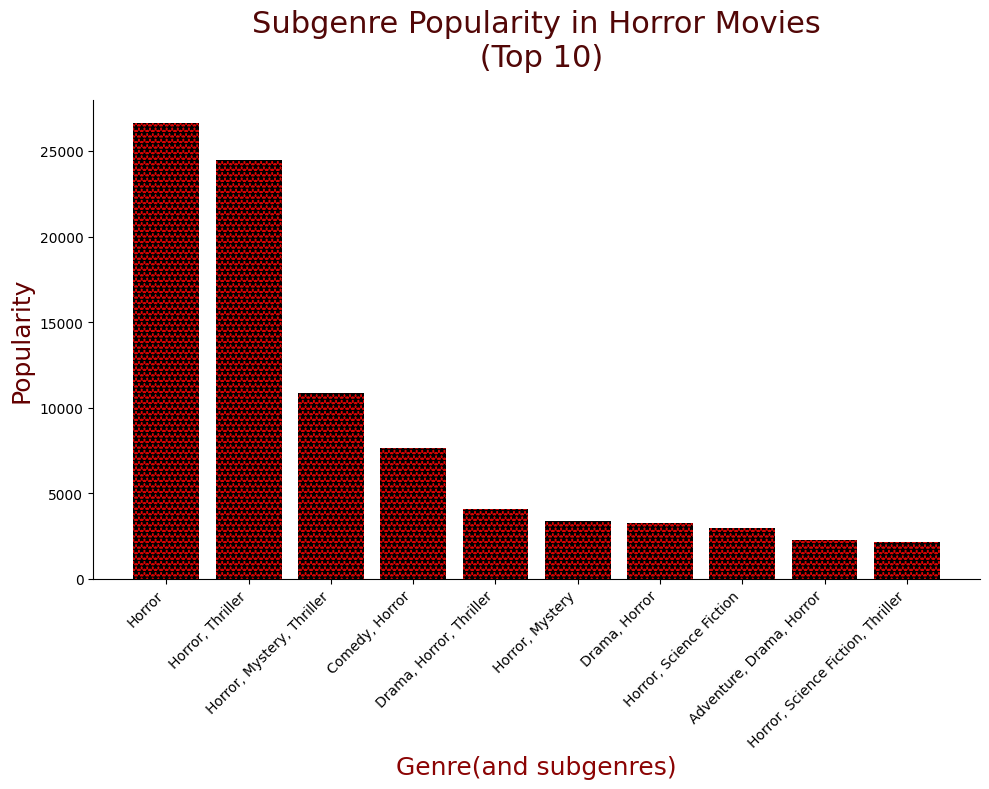

In [21]:
top_pop_genre = movie_df.groupby("genre_names")["popularity"].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(10,8))
plt.bar(top_pop_genre.index, top_pop_genre.values, color=  "#da0303", hatch= "***")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Genre(and subgenres)", fontsize= 18, color=  "#8B0404")
plt.ylabel("Popularity", fontsize= 18, color=  "#630000")
plt.title("Subgenre Popularity in Horror Movies\n (Top 10)", fontsize= 22, color=  "#520707", pad=25)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig('../firstlook_visuals/subgenrepopularity.png')
plt.show()


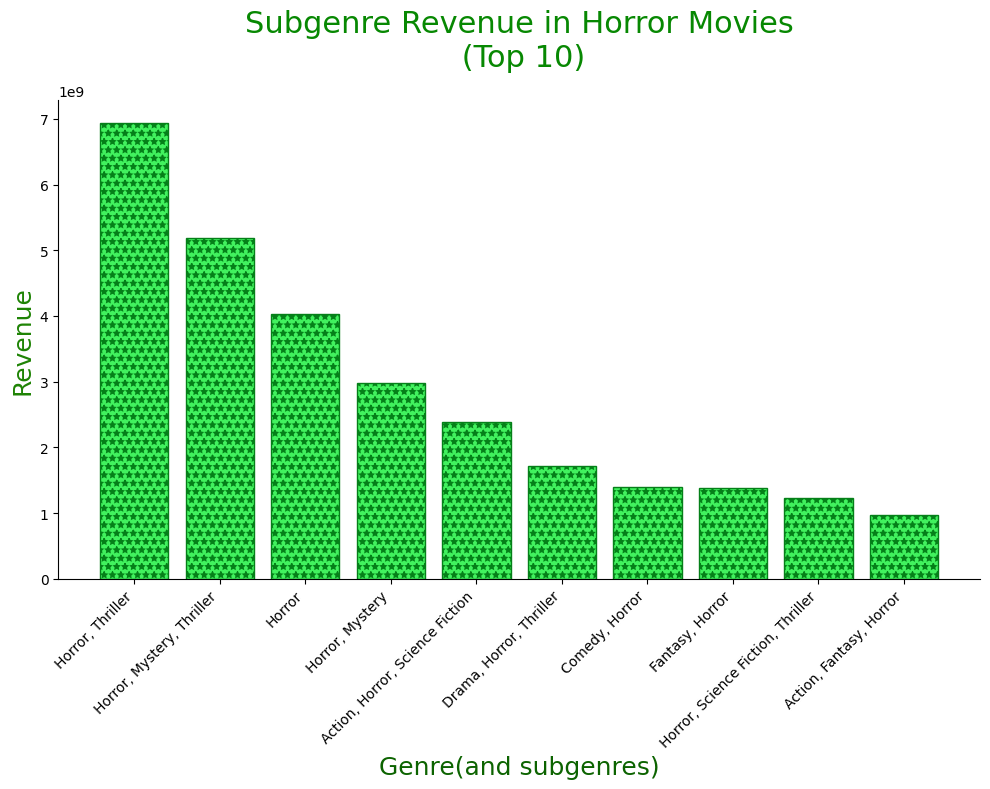

In [22]:
top_rev_genre = movie_df.groupby("genre_names")["revenue"].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(10,8))
plt.bar(top_rev_genre.index, top_rev_genre.values, color=  "#41f15e", edgecolor= "#058019", hatch= "**")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Genre(and subgenres)", fontsize= 18, color=  "#0C6300")
plt.ylabel("Revenue", fontsize= 18, color=  "#1E8304")
plt.title("Subgenre Revenue in Horror Movies\n (Top 10)", fontsize= 22, color=  "#078802", pad=25)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig('../firstlook_visuals/subgenrerevenue.png')
plt.show()




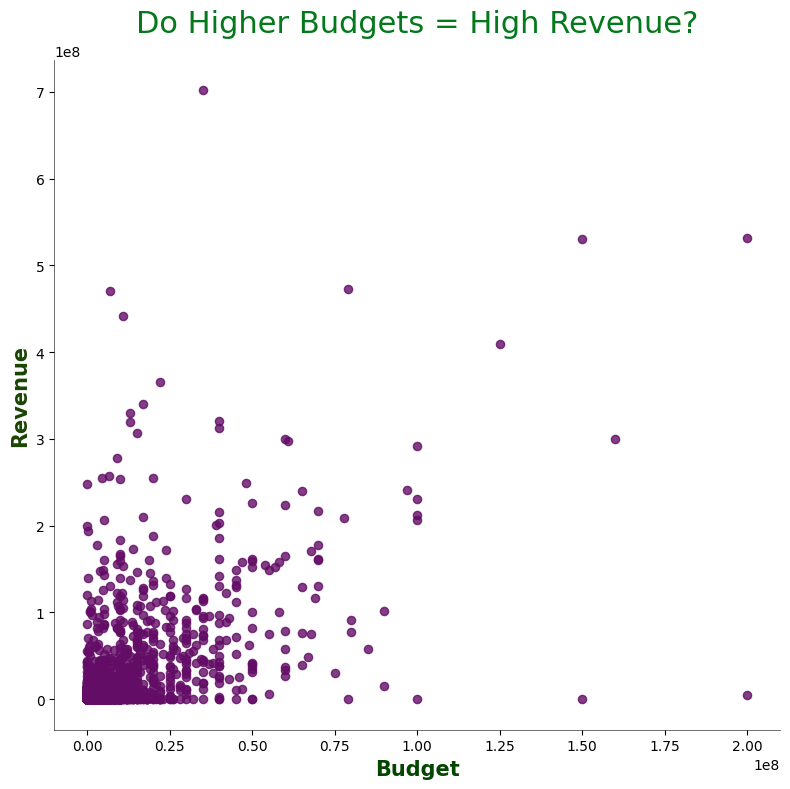

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(movie_df['budget'], movie_df['revenue'], color = "#630d66", alpha= 0.8, s= 35)


plt.xlabel("Budget", color = "#024600", fontweight= "bold", fontsize=15)
plt.ylabel("Revenue",  color = "#1A4402", fontweight= "bold", fontsize= 15)
plt.title("Do Higher Budgets = High Revenue?", fontsize=22, pad=20, color = "#03791C")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.50)
    spine.set_alpha(.8)

plt.tight_layout()
plt.savefig('../firstlook_visuals/budget_revenue_corr.png')
plt.show()

### Using ISO 639-1 Codes:
en = English  
ja = Japanese  
es = Spanish  
id = Idonesian  
fr = French  

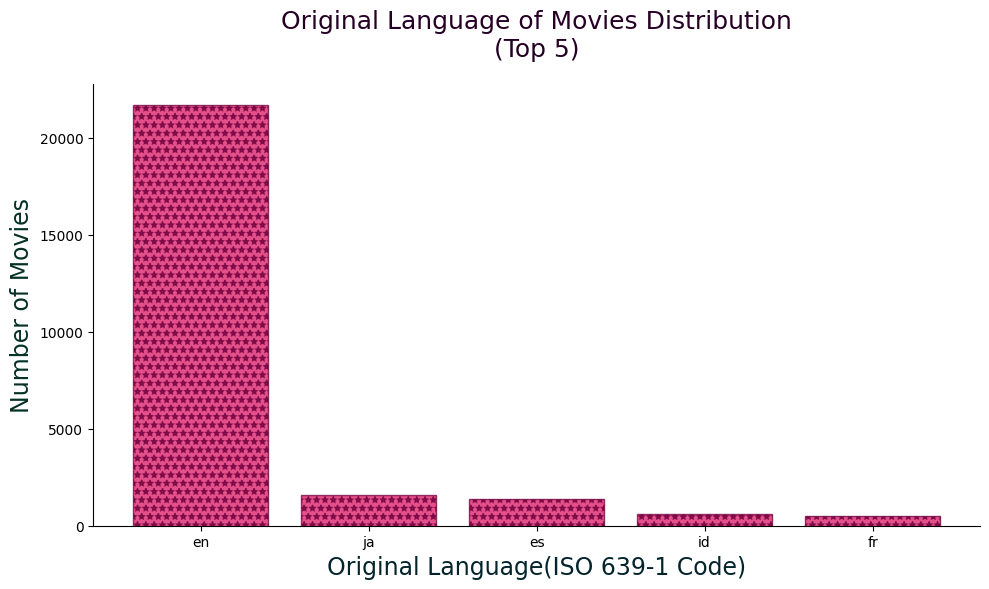

In [24]:
language_to_count = movie_df['original_language'].unique()
language_count = movie_df['original_language'].value_counts().get(language_to_count).sort_values(ascending=False)


plt.figure(figsize=(10,6))

plt.bar(
    language_count.head(5).index, 
    language_count.head(5).values, 
    color= "#db1561",
    alpha= 0.75,
    edgecolor= "#70003E",
    hatch= "**"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.xlabel("Original Language(ISO 639-1 Code)", color="#03242C", fontsize=17)
plt.ylabel("Number of Movies", color= "#043026", fontsize=17)
plt.title("Original Language of Movies Distribution\n(Top 5)", fontsize=18, pad=20, color= "#250024")

plt.tight_layout()
plt.savefig('../firstlook_visuals/originallanguage_distr.png')
plt.show()

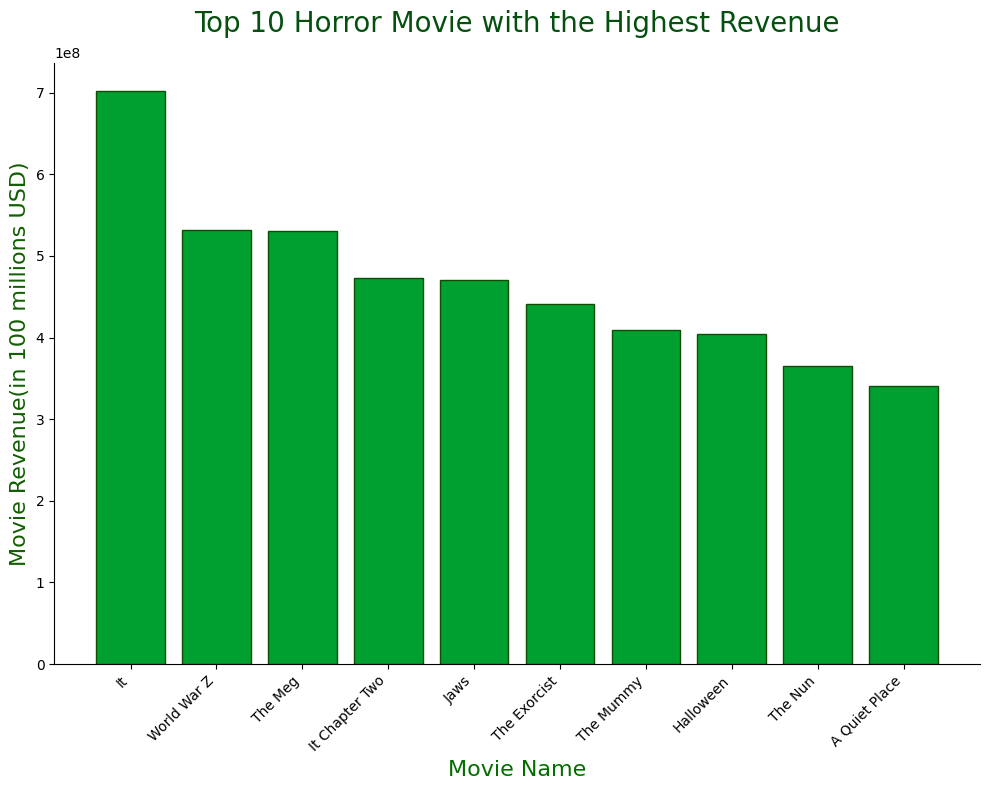

In [25]:
category = "title"
values = "revenue"
movie_rev = movie_df.groupby(category)[values].sum().sort_values(ascending=False)
movie_rev_10 = movie_rev.head(10)


plt.figure(figsize=(10,8))
plt.bar(movie_rev_10.index, movie_rev_10.values, color= "#00a030", edgecolor= "#0d4d04")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Top 10 Horror Movie with the Highest Revenue",
          fontsize= 20,
          color= "#05500F",
          pad= 22,
          loc="center")
plt.xlabel("Movie Name", color="#046d00", fontsize=16)
plt.ylabel("Movie Revenue(in 100 millions USD)", color= "#105F00", fontsize=16)
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.savefig('../firstlook_visuals/top10_movie_rev.png')
plt.show()



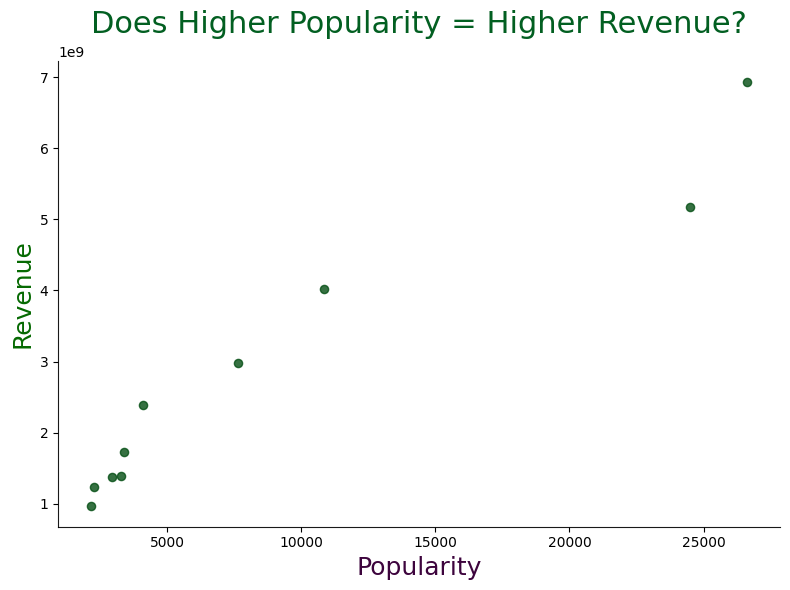

In [27]:

top_pop_genre = movie_df.groupby("genre_names")["popularity"].sum().sort_values(ascending=False).head(10)
top_rev_genre = movie_df.groupby("genre_names")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.scatter(top_pop_genre, top_rev_genre, color = "#034e13", alpha= 0.8, s= 35)

plt.xlabel("Popularity", color = "#3D043D", fontsize=18 )
plt.ylabel("Revenue",  color = "#056901", fontsize=18)
plt.title("Does Higher Popularity = Higher Revenue?", fontsize=22, pad=20, color = "#025F21")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.80)
    spine.set_alpha(.9)

plt.tight_layout()
plt.savefig('../firstlook_visuals/pop_vs_rev_top10.png')
plt.show()



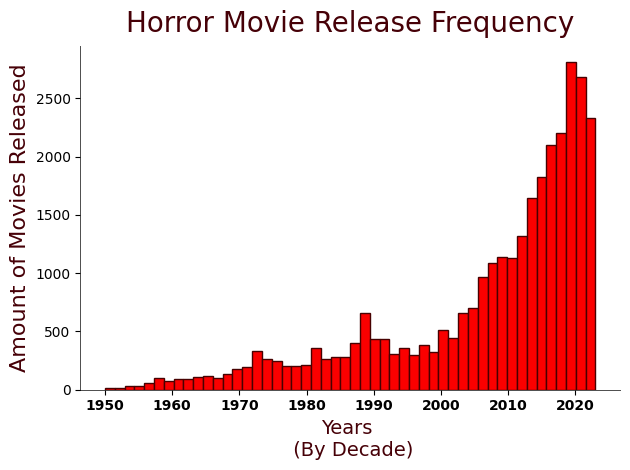

In [28]:
release_data = movie_df['release_date']
plt.hist(release_data, bins=50, color="#fa0000", edgecolor="#470101")


plt.xlabel('Years \n (By Decade)', fontsize=14, color= "#460007")
plt.ylabel('Amount of Movies Released',fontsize=16,  color= "#460007" )
plt.title('Horror Movie Release Frequency', fontsize=20, pad=10, color= "#460007")
plt.xticks(fontweight= "bold")
ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../firstlook_visuals/horror_movie_release_freq.png')
plt.show()


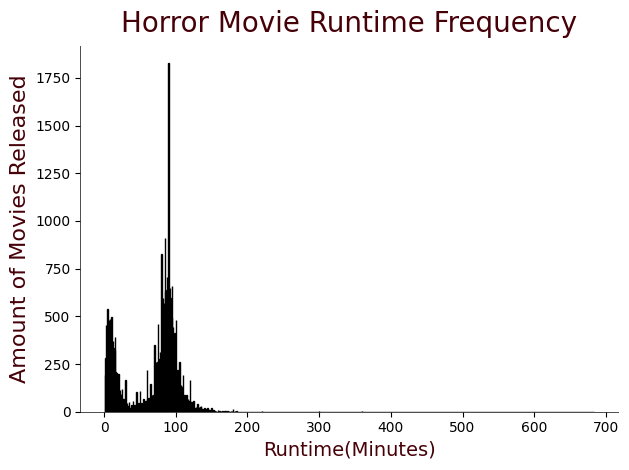

In [29]:
runtime_data = movie_df['runtime'].replace(0, np.nan)


plt.hist(runtime_data, bins=1000, color="#fa0000", edgecolor="#000000")


plt.xlabel('Runtime(Minutes)', fontsize=14, color= "#460007")
plt.ylabel('Amount of Movies Released',fontsize=16,  color= "#460007" )
plt.title('Horror Movie Runtime Frequency', fontsize=20, pad=10, color= "#460007")

ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../firstlook_visuals/horror_movie_runtime_freq.png')
plt.show()





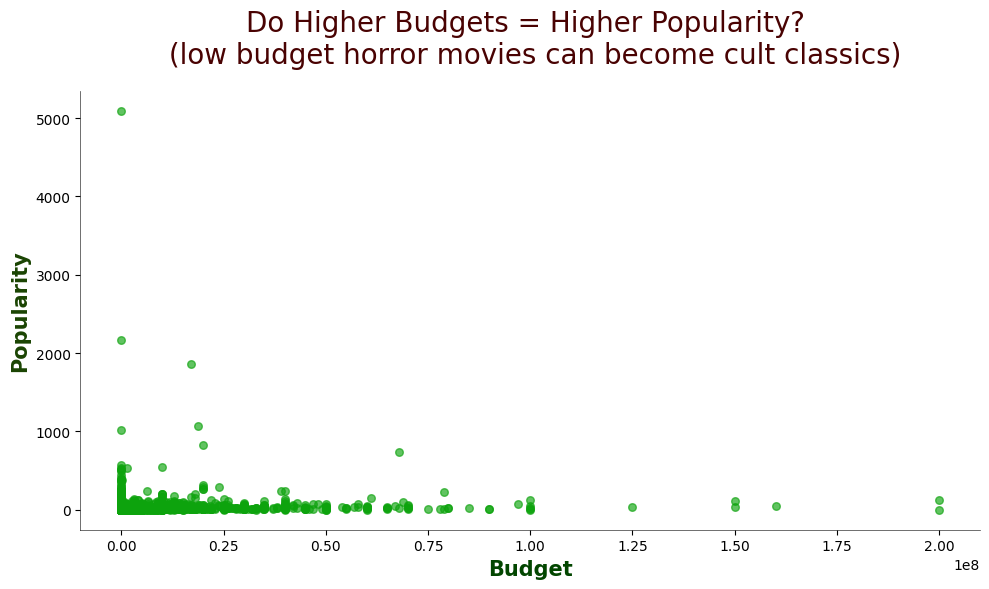

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(movie_df['budget'], movie_df['popularity'], color = "#0da30d", alpha= 0.65, s= 30)


plt.xlabel("Budget", color = "#024600", fontweight= "bold", fontsize=15)
plt.ylabel("Popularity",  color = "#1A4402", fontweight= "bold", fontsize= 15)
plt.title("Do Higher Budgets = Higher Popularity? \n (low budget horror movies can become cult classics)", fontsize=20, pad=20, color = "#490202")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.50)
    spine.set_alpha(.8)

plt.tight_layout()
plt.savefig('../firstlook_visuals/budget_popularity_corr.png')
plt.show()

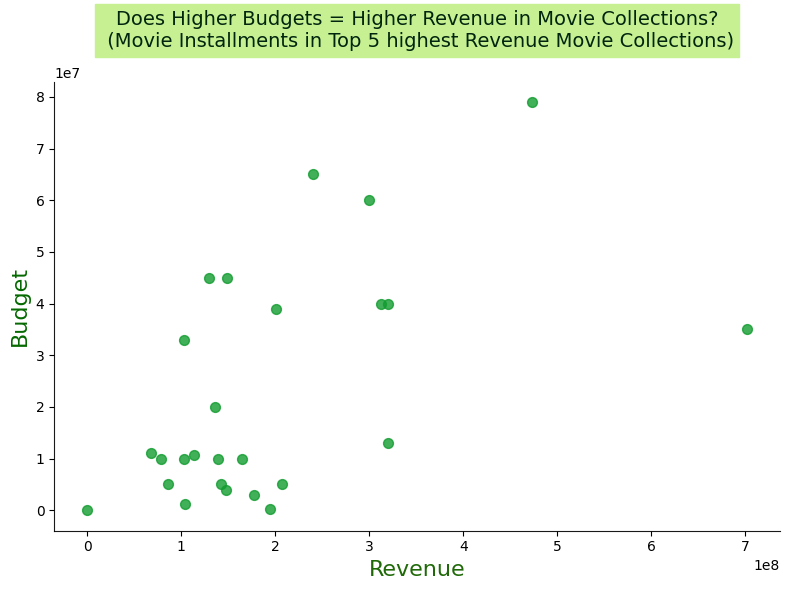

In [31]:
# error checking/ ignore

# pac_data = movie_df[movie_df['collection_name'] == 'Paranormal Activity Collection'].copy()
# pac_total_budget = pac_data['budget'].sum()
# pac_total_revenue = pac_data['revenue'].sum()

# print("paranormal activity collection")
# print(pac_total_budget) #10 s of millions
# print(pac_total_revenue) # 100s of millions

# blade_data = movie_df[movie_df['collection_name'] == 'Blade Collection'].copy()
# blade_total_budget = blade_data['budget'].sum()
# blade_total_revenue = blade_data['revenue'].sum()

# print("blade collection")
# print(blade_total_budget) 
# print(blade_total_revenue)


movie_collection_revenue = movie_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False) .head(5)
movie_coll_rev = pd.Series(movie_coll_rev) 


df1 = movie_df[movie_df['collection_name'] == 'Resident Evil Collection'].copy()
df2 = movie_df[movie_df['collection_name'] == 'It Collection'].copy()
df3 = movie_df[movie_df['collection_name'] == 'Saw Collection'].copy()
df4 = movie_df[movie_df['collection_name'] == 'Paranormal Activity Collection'].copy()
df5 = movie_df[movie_df['collection_name'] == 'The Conjuring Collection'].copy()

top_5_coll = pd.concat([df1,df2,df3,df4,df5], ignore_index= True)
#top_5_coll.info()
#26 movies total


plt.figure(figsize=(8,6))
plt.scatter(top_5_coll['revenue'], top_5_coll['budget'], color = "#129c30", alpha= 0.8, s= 50)

plt.xlabel("Revenue", color = "#1F6908", fontsize=16)
plt.ylabel("Budget",  color = "#056901", fontsize=16)
plt.title("Does Higher Budgets = Higher Revenue in Movie Collections?\n (Movie Installments in Top 5 highest Revenue Movie Collections)", fontsize=14, pad=25, color = "#01250E", backgroundcolor= "#c6f091")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(.80)
    spine.set_alpha(.9)

plt.tight_layout()
plt.savefig('../firstlook_visuals/collectionrev_bud.png')
plt.show()

